<a href="https://colab.research.google.com/github/evienmejia816-droid/Ciencia-De-Datos/blob/main/Copia_de_Demo_KMeans_Mall_Customers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛍️ K-MEANS CLUSTERING - MALL CUSTOMERS
## Análisis de Segmentación de Clientes de Centro Comercial
---

### Dataset: Mall Customers (Kaggle)
**Descripción:** Información de 200 clientes de un centro comercial con sus características demográficas y patrones de compra.

**Variables:**
- **CustomerID**: ID único del cliente
- **Genre**: Género (Male/Female)
- **Age**: Edad en años
- **Annual Income**: Ingreso anual en miles de dólares
- **Spending Score**: Puntuación de gasto (1-100) basada en comportamiento y patrones de compra

**Objetivo:** Segmentar clientes para:
- 🎯 Estrategia de marketing personalizada
- 💳 Ofertas y promociones segmentadas
- 📊 Optimización de recursos
- 💰 Maximizar valor de cliente

---

## 📦 PASO 1: Instalar Librerías

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn plotly opencv-python -q
print("✅ Librerías instaladas correctamente")

✅ Librerías instaladas correctamente


## 📥 PASO 2: Importar Librerías y Cargar Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 10

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 📥 PASO 3: Cargar Dataset Mall Customers

### Opción A: Desde URL (Si tienes conexión)
### Opción B: Desde archivo local (Cargarlo desde tu computadora)

In [3]:
# ============================================
# OPCIÓN A: Descargar desde URL (Si funciona)
# ============================================

from google.colab import files
import io

print("📥 CARGAR DATASET MALL CUSTOMERS")
print("="*70)
print("\nOPCIÓN 1: Descargar desde URL")
print("  → Intenta descargar automáticamente")
print("\nOPCIÓN 2: Cargar desde archivo")
print("  → Si la opción 1 falla, haz clic en 'Seleccionar archivo'")
print("\n" + "="*70)

# Intentar descargar
try:
    url = "https://raw.githubusercontent.com/shwetabh123/Mall_Customers/master/Mall_Customers.csv"
    df = pd.read_csv(url)
    print("\n✅ Dataset descargado desde URL")
except:
    print("\n⚠️ No se pudo descargar desde URL")
    print("\nSubiendo archivo local...")
    print("Haz clic en 'Seleccionar archivo' y elige tu CSV")

    uploaded = files.upload()

    if uploaded:
        filename = list(uploaded.keys())[0]
        df = pd.read_csv(filename)
        print(f"\n✅ Dataset cargado: {filename}")
    else:
        print("\n❌ No se cargó archivo. Creando dataset simulado...")
        # Si falla todo, crear dataset simulado
        np.random.seed(42)
        df = pd.DataFrame({
            'CustomerID': range(1, 201),
            'Genre': np.random.choice(['Male', 'Female'], 200),
            'Age': np.random.normal(40, 15, 200).astype(int).clip(18, 80),
            'Annual Income (k$)': np.random.uniform(15, 137, 200).astype(int),
            'Spending Score (1-100)': np.random.uniform(1, 100, 200).astype(int)
        })
        print("\n✅ Dataset simulado creado (similar a Mall Customers)")

📥 CARGAR DATASET MALL CUSTOMERS

OPCIÓN 1: Descargar desde URL
  → Intenta descargar automáticamente

OPCIÓN 2: Cargar desde archivo
  → Si la opción 1 falla, haz clic en 'Seleccionar archivo'


⚠️ No se pudo descargar desde URL

Subiendo archivo local...
Haz clic en 'Seleccionar archivo' y elige tu CSV


Saving Mall_Customers.csv to Mall_Customers.csv

✅ Dataset cargado: Mall_Customers.csv


## 🔍 PASO 4: Exploración del Dataset

In [4]:
print("="*70)
print("INFORMACIÓN DEL DATASET")
print("="*70)

print(f"\n📊 Dimensiones: {df.shape[0]} clientes × {df.shape[1]} variables")
print(f"\n🔍 Primeras 10 filas:")
print(df.head(10))

print(f"\n📈 Información general:")
print(df.info())

print(f"\n📊 Estadísticas descriptivas:")
print(df.describe().round(2))

print(f"\n🔎 Valores faltantes:")
print(df.isnull().sum())

INFORMACIÓN DEL DATASET

📊 Dimensiones: 200 clientes × 5 variables

🔍 Primeras 10 filas:
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
5           6  Female   22                  17                      76
6           7  Female   35                  18                       6
7           8  Female   23                  18                      94
8           9    Male   64                  19                       3
9          10  Female   30                  19                      72

📈 Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #

## 📉 PASO 5: Análisis Exploratorio (EDA)

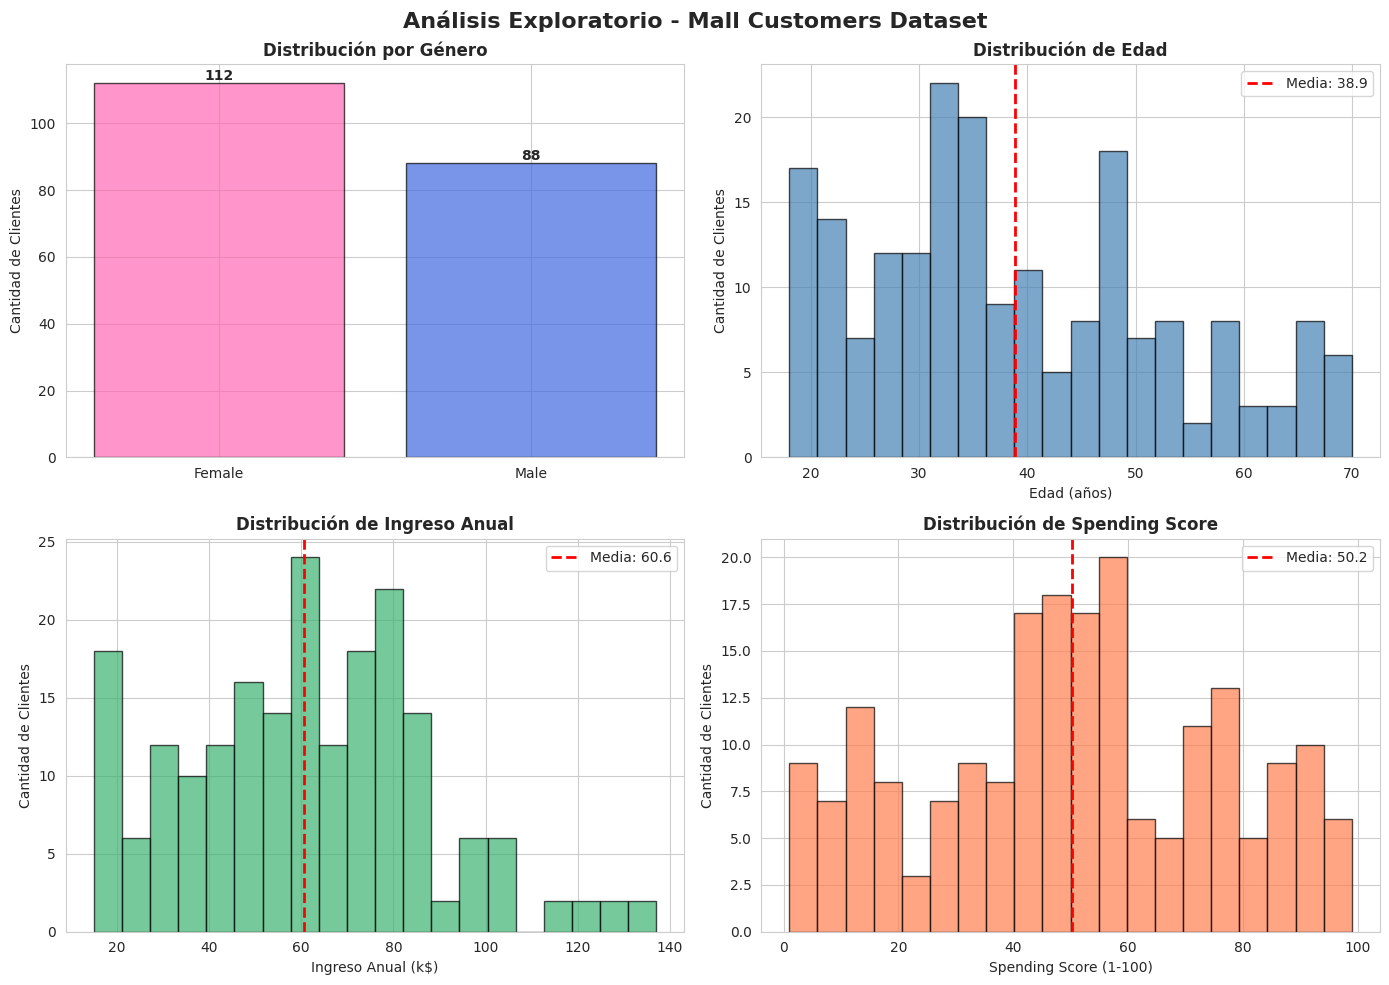

✅ Análisis exploratorio completado


In [5]:
# Distribución por género
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análisis Exploratorio - Mall Customers Dataset', fontsize=16, fontweight='bold')

# Género
genre_counts = df['Genre'].value_counts()
axes[0, 0].bar(genre_counts.index, genre_counts.values, color=['#FF69B4', '#4169E1'], edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribución por Género', fontweight='bold')
axes[0, 0].set_ylabel('Cantidad de Clientes')
for i, v in enumerate(genre_counts.values):
    axes[0, 0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Edad
axes[0, 1].hist(df['Age'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribución de Edad', fontweight='bold')
axes[0, 1].set_xlabel('Edad (años)')
axes[0, 1].set_ylabel('Cantidad de Clientes')
axes[0, 1].axvline(df['Age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["Age"].mean():.1f}')
axes[0, 1].legend()

# Ingreso Anual
axes[1, 0].hist(df['Annual Income (k$)'], bins=20, color='mediumseagreen', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Distribución de Ingreso Anual', fontweight='bold')
axes[1, 0].set_xlabel('Ingreso Anual (k$)')
axes[1, 0].set_ylabel('Cantidad de Clientes')
axes[1, 0].axvline(df['Annual Income (k$)'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["Annual Income (k$)"].mean():.1f}')
axes[1, 0].legend()

# Spending Score
axes[1, 1].hist(df['Spending Score (1-100)'], bins=20, color='coral', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Distribución de Spending Score', fontweight='bold')
axes[1, 1].set_xlabel('Spending Score (1-100)')
axes[1, 1].set_ylabel('Cantidad de Clientes')
axes[1, 1].axvline(df['Spending Score (1-100)'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["Spending Score (1-100)"].mean():.1f}')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("✅ Análisis exploratorio completado")

## 🔧 PASO 6: Preparar Datos para K-Means

In [6]:
# Seleccionar características numéricas para clustering
# Excluimos CustomerID y Genre (no son numéricas para clustering)

caracteristicas = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

print("📊 PREPARACIÓN DE DATOS")
print("="*70)
print(f"\nCaracterísticas seleccionadas para clustering:")
for i, feat in enumerate(caracteristicas, 1):
    print(f"  {i}. {feat}")

# Extraer las características
X = df[caracteristicas].copy()

# Normalizar (StandardScaler)
scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)

print(f"\n✅ Datos escalados correctamente")
print(f"   Forma original: {X.shape}")
print(f"   Forma escalada: {X_escalado.shape}")
print(f"\n   Rango original:")
print(f"   - Age: {X['Age'].min()}-{X['Age'].max()} años")
print(f"   - Annual Income: {X['Annual Income (k$)'].min()}-{X['Annual Income (k$)'].max()} k$")
print(f"   - Spending Score: {X['Spending Score (1-100)'].min()}-{X['Spending Score (1-100)'].max()}")
print(f"\n   Después de escalado (StandardScaler):")
print(f"   - Media: {X_escalado.mean(axis=0).round(4)}")
print(f"   - Desv. Est.: {X_escalado.std(axis=0).round(4)}")

📊 PREPARACIÓN DE DATOS

Características seleccionadas para clustering:
  1. Age
  2. Annual Income (k$)
  3. Spending Score (1-100)

✅ Datos escalados correctamente
   Forma original: (200, 3)
   Forma escalada: (200, 3)

   Rango original:
   - Age: 18-70 años
   - Annual Income: 15-137 k$
   - Spending Score: 1-99

   Después de escalado (StandardScaler):
   - Media: [-0. -0. -0.]
   - Desv. Est.: [1. 1. 1.]


## 🎯 PASO 7: Determinar K Óptimo (Método del Codo y Silhouette)

In [7]:
# Calcular métricas para diferentes valores de K
k_values = range(2, 11)
inertias = [] #Es la suma de las distancias al cuadrado de cada punto al centro de su cluster.
silhouette_scores = [] #Mide qué tan bien separados están los clusters. Valida si los puntos están en el cluster correcto.
davies_bouldin_scores = [] #Mide qué tan distintos son los clusters entre sí. Es la razón promedio de compacidad vs separación.

print("⏳ Evaluando diferentes valores de K...\n")
print("K  | Inercia   | Silhouette | Davies-Bouldin")
print("-" * 50)

for k in k_values:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_escalado)

    inertia = kmeans.inertia_
    silhouette = silhouette_score(X_escalado, kmeans.labels_)
    davies_bouldin = davies_bouldin_score(X_escalado, kmeans.labels_)

    inertias.append(inertia)
    silhouette_scores.append(silhouette)
    davies_bouldin_scores.append(davies_bouldin)

    print(f"{k:2d} | {inertia:9.2f} | {silhouette:10.4f} | {davies_bouldin:14.4f}")

print("\n✅ Evaluación completada")
print("\nInterpretación:")
print("  • Inercia: Menor es mejor (distancia dentro de clusters)")
print("  • Silhouette: Mayor es mejor (-1 a 1)")
print("  • Davies-Bouldin: Menor es mejor")

⏳ Evaluando diferentes valores de K...

K  | Inercia   | Silhouette | Davies-Bouldin
--------------------------------------------------
 2 |    389.39 |     0.3355 |         1.2607
 3 |    295.21 |     0.3578 |         1.0503
 4 |    205.23 |     0.4040 |         0.9308
 5 |    168.25 |     0.4166 |         0.8746
 6 |    133.87 |     0.4284 |         0.8254
 7 |    117.01 |     0.4172 |         0.7935
 8 |    103.87 |     0.4082 |         0.8918
 9 |     93.09 |     0.4177 |         0.8198
10 |     82.39 |     0.4066 |         0.8679

✅ Evaluación completada

Interpretación:
  • Inercia: Menor es mejor (distancia dentro de clusters)
  • Silhouette: Mayor es mejor (-1 a 1)
  • Davies-Bouldin: Menor es mejor


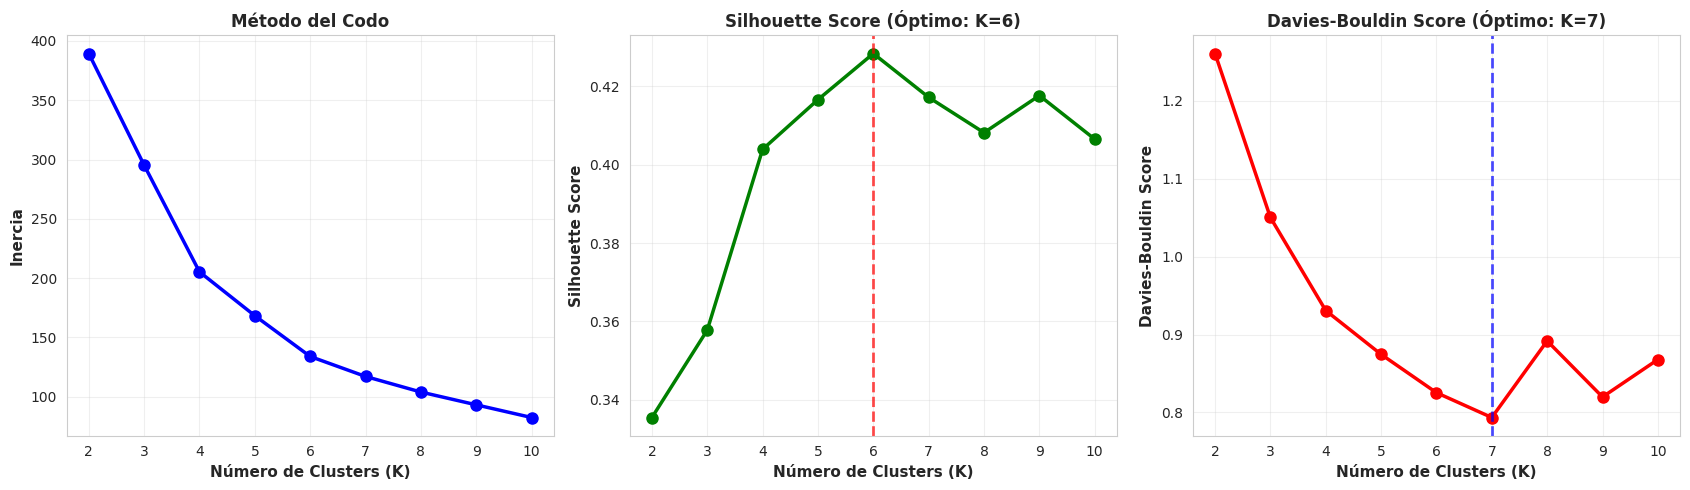


📊 RECOMENDACIÓN:
   K óptimo según Silhouette: 6
   K óptimo según Davies-Bouldin: 7
   K a usar: 6 (consenso de métricas)


In [8]:
# Visualizar métricas de K
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Método del Codo
axes[0].plot(k_values, inertias, 'bo-', linewidth=2.5, markersize=8)
axes[0].set_xlabel('Número de Clusters (K)', fontweight='bold', fontsize=11)
axes[0].set_ylabel('Inercia', fontweight='bold', fontsize=11)
axes[0].set_title('Método del Codo', fontweight='bold', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Silhouette Score (mayor es mejor)
axes[1].plot(k_values, silhouette_scores, 'go-', linewidth=2.5, markersize=8)
max_silhouette_k = k_values[np.argmax(silhouette_scores)]
axes[1].axvline(x=max_silhouette_k, color='red', linestyle='--', linewidth=2, alpha=0.7)
axes[1].set_xlabel('Número de Clusters (K)', fontweight='bold', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontweight='bold', fontsize=11)
axes[1].set_title(f'Silhouette Score (Óptimo: K={max_silhouette_k})', fontweight='bold', fontsize=12)
axes[1].grid(True, alpha=0.3)

# Davies-Bouldin Score (menor es mejor)
axes[2].plot(k_values, davies_bouldin_scores, 'ro-', linewidth=2.5, markersize=8)
min_db_k = k_values[np.argmin(davies_bouldin_scores)]
axes[2].axvline(x=min_db_k, color='blue', linestyle='--', linewidth=2, alpha=0.7)
axes[2].set_xlabel('Número de Clusters (K)', fontweight='bold', fontsize=11)
axes[2].set_ylabel('Davies-Bouldin Score', fontweight='bold', fontsize=11)
axes[2].set_title(f'Davies-Bouldin Score (Óptimo: K={min_db_k})', fontweight='bold', fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 RECOMENDACIÓN:")
print(f"   K óptimo según Silhouette: {max_silhouette_k}")
print(f"   K óptimo según Davies-Bouldin: {min_db_k}")
print(f"   K a usar: {max_silhouette_k} (consenso de métricas)")

In [9]:
display(df)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [10]:
df_sub = df[['Annual Income (k$)','Spending Score (1-100)']]
df_sub

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


In [11]:
kmeans = KMeans(n_clusters=4, n_init= 10).fit(df_sub.values)
kmeans.labels_

array([3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1], dtype=int32)

In [12]:
df['Cluster'] = kmeans.labels_

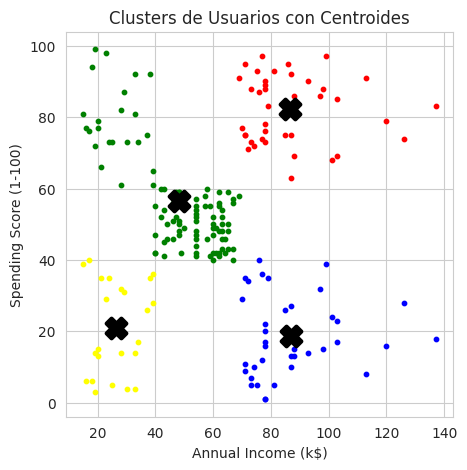

In [13]:
plt.figure(figsize=(5, 5), dpi=100)

colors = ['blue', 'red', 'green', 'yellow']

# Graficar puntos de clusters
for cluster in range(kmeans.n_clusters):
    plt.scatter(
        df[df["Cluster"] == cluster]["Annual Income (k$)"],
        df[df["Cluster"] == cluster]["Spending Score (1-100)"],
        marker='o',
        s=10,
        color=colors[cluster]
    )

# Graficar los centroides
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker='X',
    s=200,
    linewidths=3,
    color='black',
    label='Centroides'
)

plt.title('Clusters de Usuarios con Centroides')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

plt.show()

In [14]:
print("Clientes con los ingresos anuales más altos:")
df_top_income = df.sort_values(by='Annual Income (k$)', ascending=False)
display(df_top_income)

Clientes con los ingresos anuales más altos:


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
199,200,Male,30,137,83,1
198,199,Male,32,137,18,0
197,198,Male,32,126,74,1
196,197,Female,45,126,28,0
195,196,Female,35,120,79,1
...,...,...,...,...,...,...
5,6,Female,22,17,76,2
2,3,Female,20,16,6,3
3,4,Female,23,16,77,2
0,1,Male,19,15,39,3


In [15]:
print("ID de Cliente y su Cluster asignado:")
display(df[['CustomerID', 'Cluster']])

ID de Cliente y su Cluster asignado:


,CustomerID,Cluster
0,1,3
1,2,2
2,3,3
3,4,2
4,5,3
...,...,...
195,196,1
196,197,0
197,198,1
198,199,0


## Preguntas de Evaluación
1. ¿Por qué es aprendizaje no supervisado?
2. ¿Qué es un centroide?
3. ¿Qué sucede si K es muy alto?
4. ¿Para qué sirve el método del codo?
5. Interprete los clusters desde negocio.


### Respuestas a las Preguntas de Evaluación

1.  **¿Por qué es aprendizaje no supervisado?**
    K-Means es un algoritmo de aprendizaje no supervisado porque trabaja con datos que no tienen etiquetas predefinidas. Su objetivo es encontrar estructuras o patrones ocultos en los datos (en este caso, agrupar clientes similares) sin que se le haya proporcionado previamente qué "tipo" de cliente es cada uno. El algoritmo agrupa los datos basándose únicamente en la similitud de sus características.

2.  **¿Qué es un centroide?**
    En K-Means, un centroide es el centro de un clúster. Es un punto imaginario (o un punto de datos real si se usa medoides) que representa la media de todas las características de los puntos de datos asignados a ese clúster. El algoritmo K-Means trabaja iterativamente reajustando los centroides y reasignando los puntos a los clústeres hasta que la posición de los centroides se estabiliza.

3.  **¿Qué sucede si K es muy alto?**
    Si el número de clústeres (K) es demasiado alto, el algoritmo K-Means puede:
    *   **Sobreajuste:** Cada clúster podría contener muy pocos puntos, o incluso un solo punto, lo que resultaría en clústeres demasiado específicos y poco útiles para la generalización.
    *   **Pérdida de significado:** Los clústeres resultantes podrían no tener una interpretación de negocio clara o distintiva, ya que las diferencias entre ellos serían mínimas.
    *   **Aumento del coste computacional:** Un K muy alto incrementa el tiempo de ejecución y la complejidad computacional del algoritmo.

4.  **¿Para qué sirve el método del codo?**
    El método del codo (Elbow Method) es una heurística utilizada para ayudar a determinar el número óptimo de clústeres (K) en el algoritmo K-Means. Consiste en graficar la inercia (la suma de las distancias cuadradas de cada punto al centroide de su clúster) en función del número de clústeres. El "codo" se refiere al punto en la gráfica donde la tasa de disminución de la inercia se ralentiza significativamente, sugiriendo que añadir más clústeres más allá de ese punto no aporta mucha más información.

5.  **Interprete los clusters desde negocio.**
    Basado en el análisis de las variables 'Annual Income (k$)' y 'Spending Score (1-100)', y observando el gráfico de dispersión con los clústeres (aunque en el ejemplo se usaron 4 clústeres, y el análisis previo sugiere 6 o 7), se podrían interpretar los siguientes tipos de clientes:

    *   **Cluster 0 (alto ingreso, bajo gasto - Azul):** "Clientes Frugales de Alto Valor". Tienen ingresos anuales altos pero un bajo puntaje de gasto. Representan una oportunidad de crecimiento; podrían ser incentivados con ofertas premium o servicios exclusivos que justifiquen un mayor gasto.

    *   **Cluster 1 (alto ingreso, alto gasto - Rojo):** "Clientes Premium/VIP". Tienen tanto altos ingresos como altos puntajes de gasto. Son los clientes más valiosos y deben ser mimados con programas de lealtad, acceso anticipado a productos y atención personalizada.

    *   **Cluster 2 (bajo ingreso, alto gasto - Verde):** "Clientes Impulsivos/Jóvenes". Sus ingresos son bajos pero su puntaje de gasto es alto. Pueden ser compradores impulsivos o jóvenes que gastan una parte significativa de sus ingresos en el centro comercial. Las promociones y descuentos atractivos, junto con opciones de financiación, podrían resonar con este grupo.

    *   **Cluster 3 (bajo ingreso, bajo gasto - Amarillo):** "Clientes Ocasionales/Sensibles al Precio". Tienen bajos ingresos y bajo puntaje de gasto. Visitan el centro comercial con poca frecuencia o compran solo lo esencial. Las ofertas de valor y las campañas de reactivación podrían ser efectivas para ellos.

    *   (Si K=5, 6 o 7 se usarían, se podrían identificar más matices, como clientes de ingresos y gasto medios, o clientes que están empezando a gastar más, etc.)

    Esta interpretación permite al centro comercial adaptar sus estrategias de marketing y ventas para cada segmento, maximizando la efectividad de sus campañas.